<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/AssetPricingModels/AssetPricingModels/CAPM_and_Kalman_Filter_CAPM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pykalman

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pykalman import KalmanFilter

Use the 13-week T-Bill (^IRX) to get a dynamic risk-free rate, which is more accurate than assuming a flat 0% or 4%.

In [ ]:
assets = ["AAPL", "^GSPC", "^IRX"]

start = "2019-01-01"
end = "2024-01-01"

data = yf.download(assets, start=start, end=end, auto_adjust=False)["Adj Close"]
data.dropna(inplace=True)

[*********************100%***********************]  3 of 3 completed


In [ ]:
rf_annual = data["^IRX"] / 100
rf_daily = rf_annual / 252

In [ ]:
returns = data[["AAPL", "^GSPC"]].pct_change().dropna()
rf_daily = rf_daily.loc[returns.index]

In [ ]:
excess_stock = returns["AAPL"] - rf_daily
excess_market = returns["^GSPC"] - rf_daily

In [ ]:
X = sm.add_constant(excess_market) # Adds a column of 1s to the matrix of excess_market to allow the OLS to predict an intercept
model = sm.OLS(excess_stock, X).fit()

alpha, beta = model.params

In [ ]:
print("Alpha (daily):", round(alpha, 6))
print("Beta:", round(beta, 4))
print(model.summary())

Alpha (daily): 0.000785
Beta: 1.2157
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.647
Model:                            OLS   Adj. R-squared:                  0.646
Method:                 Least Squares   F-statistic:                     2297.
Date:                Wed, 14 Jan 2026   Prob (F-statistic):          7.91e-286
Time:                        05:39:31   Log-Likelihood:                 3769.1
No. Observations:                1257   AIC:                            -7534.
Df Residuals:                    1255   BIC:                            -7524.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          

# CAPM Model using a Rolling Beta to counter the fixed Beta Assumption in the Previous Model

In [ ]:
window = 252  # 1 trading year

rolling_beta = (
    excess_stock.rolling(window)
    .cov(excess_market)
    / excess_market.rolling(window).var()
)                                         # Statistically equivalent to rolling OLS for beta, and more efficient

rolling_beta.tail()

,0
Date,
2023-12-22,1.142533
2023-12-26,1.134080
2023-12-27,1.136911
2023-12-28,1.134069
2023-12-29,1.121394


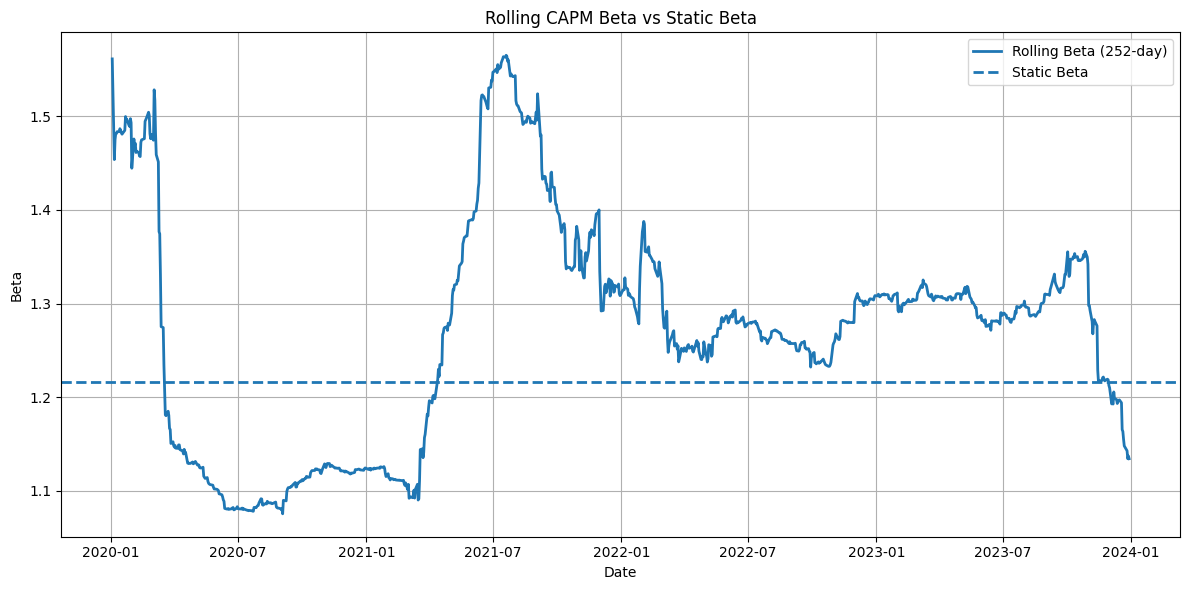

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(rolling_beta_ols, label="Rolling Beta (252-day)", linewidth=2)
plt.axhline(beta, linestyle="--", label="Static Beta", linewidth=2)

plt.title("Rolling CAPM Beta vs Static Beta")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
rolling_alpha = (
    excess_stock.rolling(window).mean()
    - rolling_beta * excess_market.rolling(window).mean()
)

rolling_alpha.tail()

,0
Date,
2023-12-22,0.000591
2023-12-26,0.000596
2023-12-27,0.000627
2023-12-28,0.000673
2023-12-29,0.000741


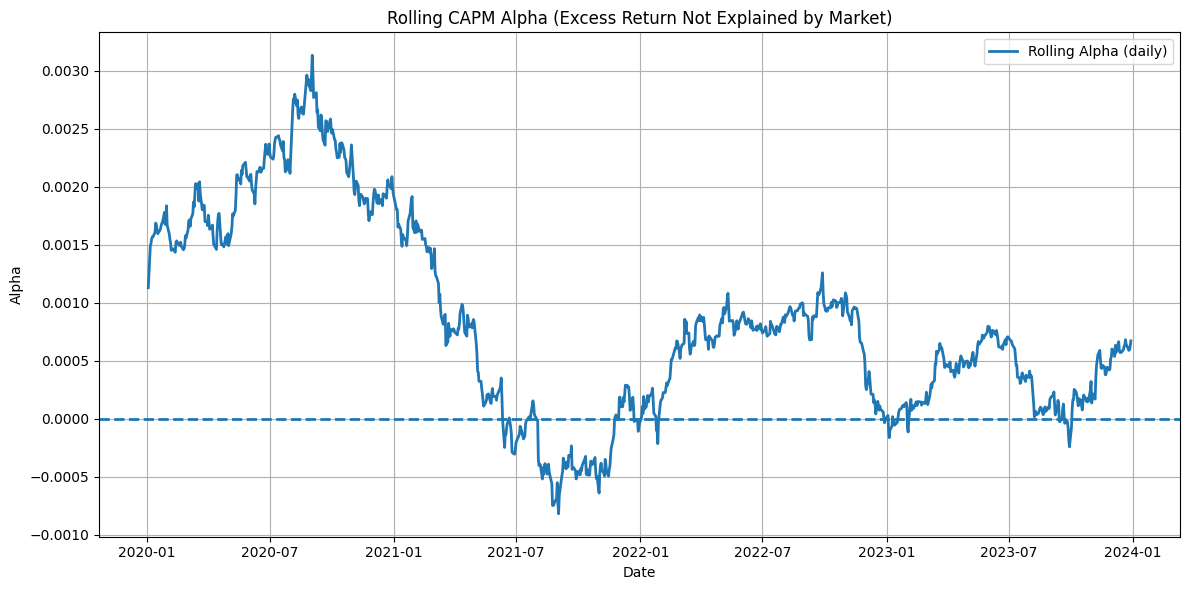

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(rolling_alpha_ols, label="Rolling Alpha (daily)", linewidth=2)
plt.axhline(0, linestyle="--", linewidth=2)

plt.title("Rolling CAPM Alpha (Excess Return Not Explained by Market)")
plt.xlabel("Date")
plt.ylabel("Alpha")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
rolling_rf = rf_daily.rolling(window).mean()
rolling_market_return = returns["^GSPC"].rolling(window).mean()

rolling_expected_return = (
    rolling_rf
    + rolling_beta * (rolling_market_return - rolling_rf)
)

rolling_expected_return

,0
Date,
2019-01-03,NaN
2019-01-04,NaN
2019-01-07,NaN
2019-01-08,NaN
2019-01-09,NaN
...,...
2023-12-22,0.000935
2023-12-26,0.001014
2023-12-27,0.000996


# Rolling CAPM using OLS(Generic)

In [ ]:
def rolling_ols(y, x, window):
    alphas = []
    betas = []
    dates = []

    for i in range(window, len(y)):
        y_window = y.iloc[i-window:i]
        x_window = x.iloc[i-window:i]

        X = sm.add_constant(x_window)
        model = sm.OLS(y_window, X).fit()

        alphas.append(model.params.iloc[0])  # alpha
        betas.append(model.params.iloc[1])   # beta
        dates.append(y.index[i])

    return (
        pd.Series(alphas, index=dates, name="alpha"),
        pd.Series(betas, index=dates, name="beta")
    )

In [ ]:
rolling_alpha_ols, rolling_beta_ols = rolling_ols(
    excess_stock, excess_market, window=252
)

print(rolling_alpha_ols, rolling_beta_ols)

2020-01-03    0.001131
2020-01-06    0.001492
2020-01-07    0.001512
2020-01-08    0.001553
2020-01-09    0.001570
                ...   
2023-12-22    0.000644
2023-12-26    0.000591
2023-12-27    0.000596
2023-12-28    0.000627
2023-12-29    0.000673
Name: alpha, Length: 1005, dtype: float64 2020-01-03    1.561529
2020-01-06    1.453893
2020-01-07    1.475028
2020-01-08    1.481699
2020-01-09    1.481781
                ...   
2023-12-22    1.147780
2023-12-26    1.142533
2023-12-27    1.134080
2023-12-28    1.136911
2023-12-29    1.134069
Name: beta, Length: 1005, dtype: float64


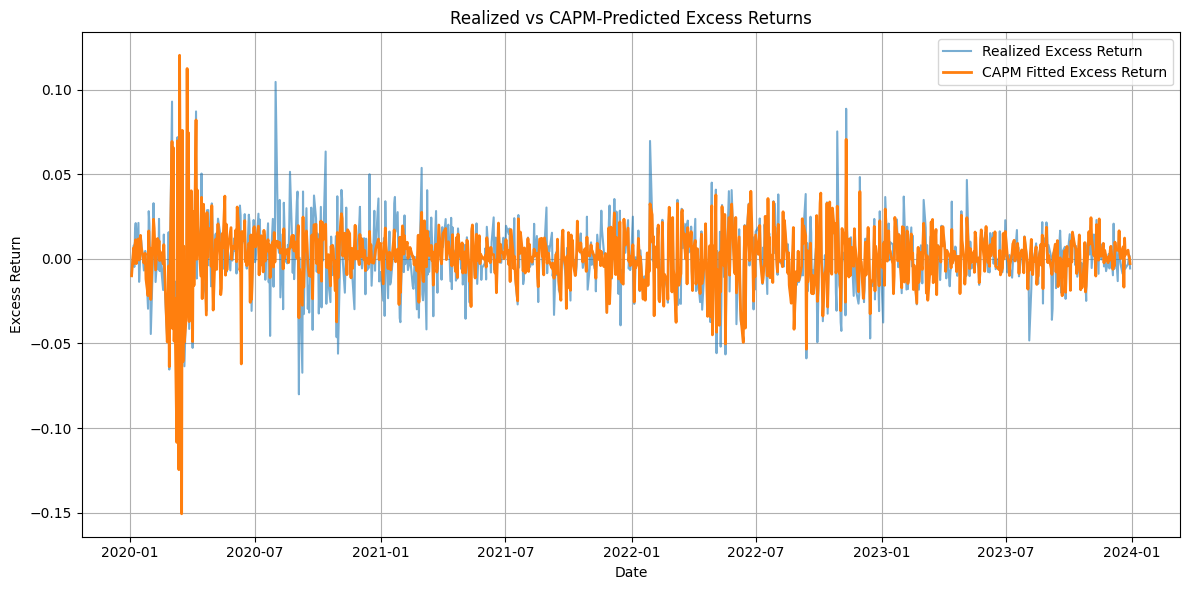

In [ ]:
capm_fitted = rolling_alpha_ols + rolling_beta_ols * excess_market.loc[rolling_beta_ols.index]

plt.figure(figsize=(12, 6))
plt.plot(excess_stock.loc[capm_fitted.index], label="Realized Excess Return", alpha=0.6)
plt.plot(capm_fitted, label="CAPM Fitted Excess Return", linewidth=2)

plt.title("Realized vs CAPM-Predicted Excess Returns")
plt.xlabel("Date")
plt.ylabel("Excess Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

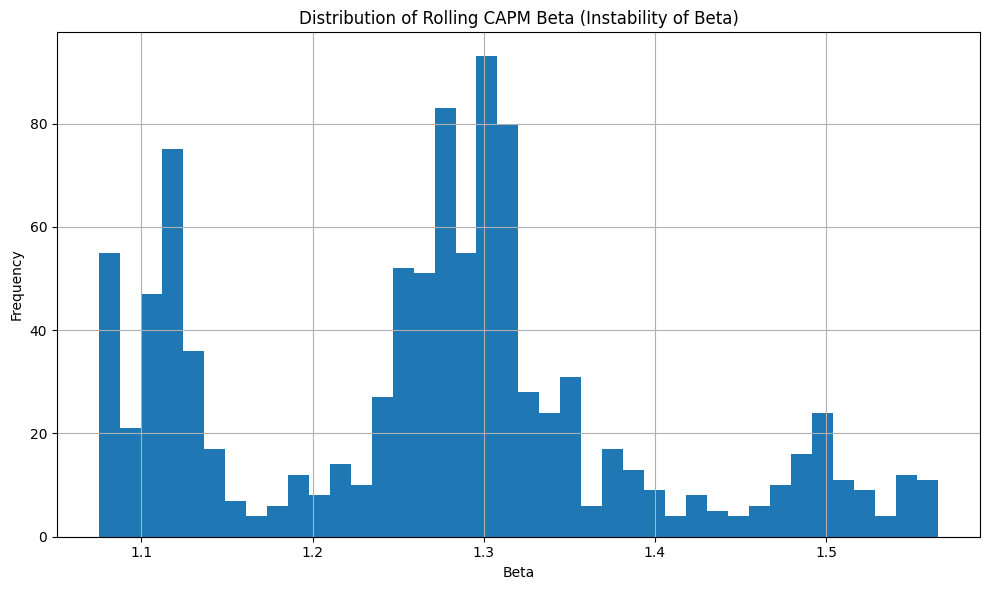

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(rolling_beta_ols.dropna(), bins=40)
plt.title("Distribution of Rolling CAPM Beta (Instability of Beta)")
plt.xlabel("Beta")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

Rolling R-Squared for the Rolling CAPM OLS Model

In [ ]:
window = 252
rolling_r2 = []

for i in range(window, len(excess_stock)):
    y = excess_stock.iloc[i-window:i]
    x = excess_market.iloc[i-window:i]
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    rolling_r2.append(model.rsquared)

rolling_r2 = pd.Series(
    rolling_r2,
    index=excess_stock.index[window:]
)

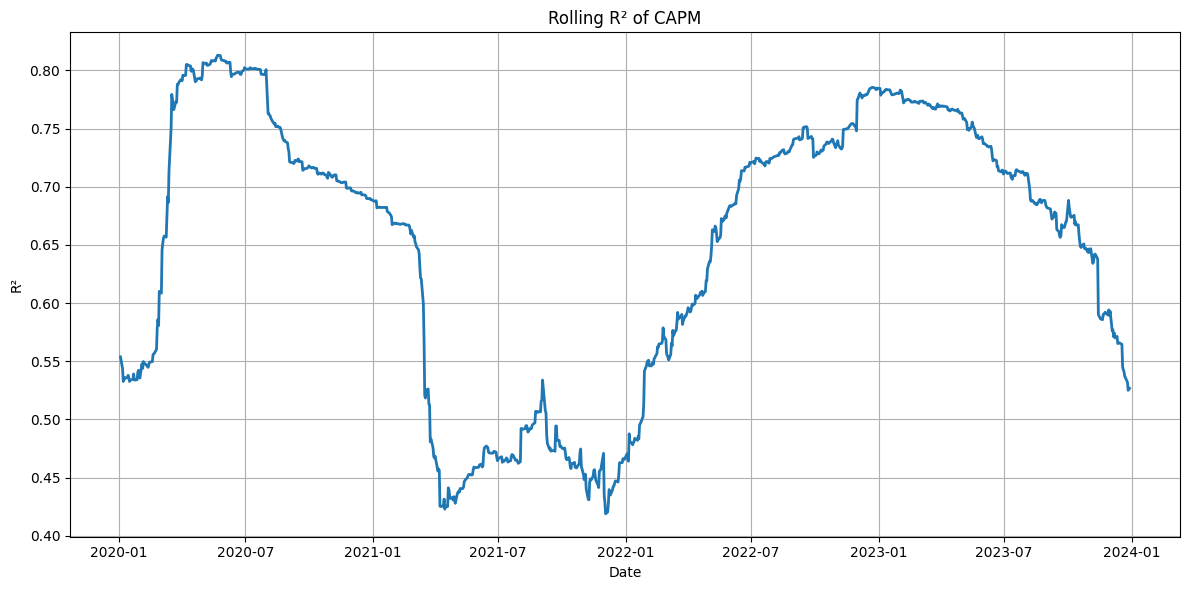

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(rolling_r2, linewidth=2)

plt.title("Rolling R² of CAPM")
plt.xlabel("Date")
plt.ylabel("R²")
plt.grid(True)
plt.tight_layout()
plt.show()

# Why Kalman Filter CAPM?
Problem with Rolling CAPM

Rolling windows assume:
*   β is constant inside the window
*   β changes suddenly when the window shifts

This creates:
*   Artificial jumps
*   Window-size sensitivity
*   Poor real-time estimates

# Kalman Filter Idea

Instead, assume beta evolves smoothly over time:

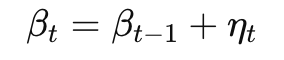

where:

𝜂𝑡 = small random change (process noise)

This gives us continuous, adaptive beta estimates.


# State-Space Formulation of CAPM

**Observation equation (CAPM)**

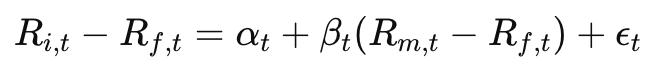

** State equations **

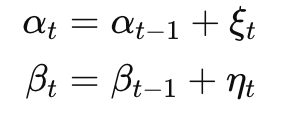

This is a linear Gaussian state-space model → perfect for Kalman Filter.

# Practical Simplification (Standard)

Most implementations:
* Let alpha be constant
* Let beta be time-varying

So we model:

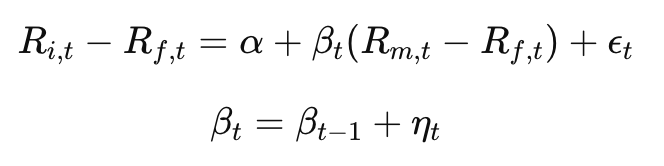

This keeps things stable and interpretable.

**We define the observation matrix dynamically:**

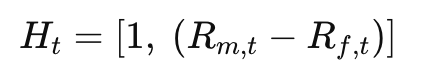

In [ ]:
y = excess_stock.values
x = excess_market.values

# Observation matrix: [1, market_excess_return]
observation_matrices = np.column_stack(
    [np.ones(len(x)), x]
)

observation_matrices

array([[ 1.00000000e+00, -2.48501828e-02],
       [ 1.00000000e+00,  3.42421432e-02],
       [ 1.00000000e+00,  6.91706184e-03],
       ...,
       [ 1.00000000e+00,  1.22271965e-03],
       [ 1.00000000e+00,  1.63111119e-04],
       [ 1.00000000e+00, -3.03203056e-03]])

In [ ]:
kf = KalmanFilter(
    n_dim_obs=1,
    n_dim_state=2,  # [alpha, beta]

    transition_matrices=np.eye(2),  # random walk
    observation_matrices=observation_matrices[:, np.newaxis, :],

    transition_covariance=np.diag([1e-6, 1e-4]),  # smooth alpha, flexible beta
    observation_covariance=1e-3,

    initial_state_mean=[0, 1],
    initial_state_covariance=np.eye(2)
)

kf

In [ ]:
state_means, state_covs = kf.filter(y)

alpha_kf = pd.Series(state_means[:, 0], index=excess_stock.index)
beta_kf = pd.Series(state_means[:, 1], index=excess_stock.index)

alpha_kf, beta_kf

(Date
 2019-01-03   -0.074730
 2019-01-04   -0.037426
 2019-01-07   -0.030147
 2019-01-08   -0.022645
 2019-01-09   -0.016120
                 ...   
 2023-12-22   -0.000858
 2023-12-26   -0.001080
 2023-12-27   -0.001083
 2023-12-28   -0.000993
 2023-12-29   -0.001021
 Length: 1257, dtype: float64,
 Date
 2019-01-03    1.001857
 2019-01-04    1.895077
 2019-01-07    1.906855
 2019-01-08    1.941612
 2019-01-09    1.918828
                 ...   
 2023-12-22    1.230091
 2023-12-26    1.229496
 2023-12-27    1.229497
 2023-12-28    1.229364
 2023-12-29    1.229501
 Length: 1257, dtype: float64)

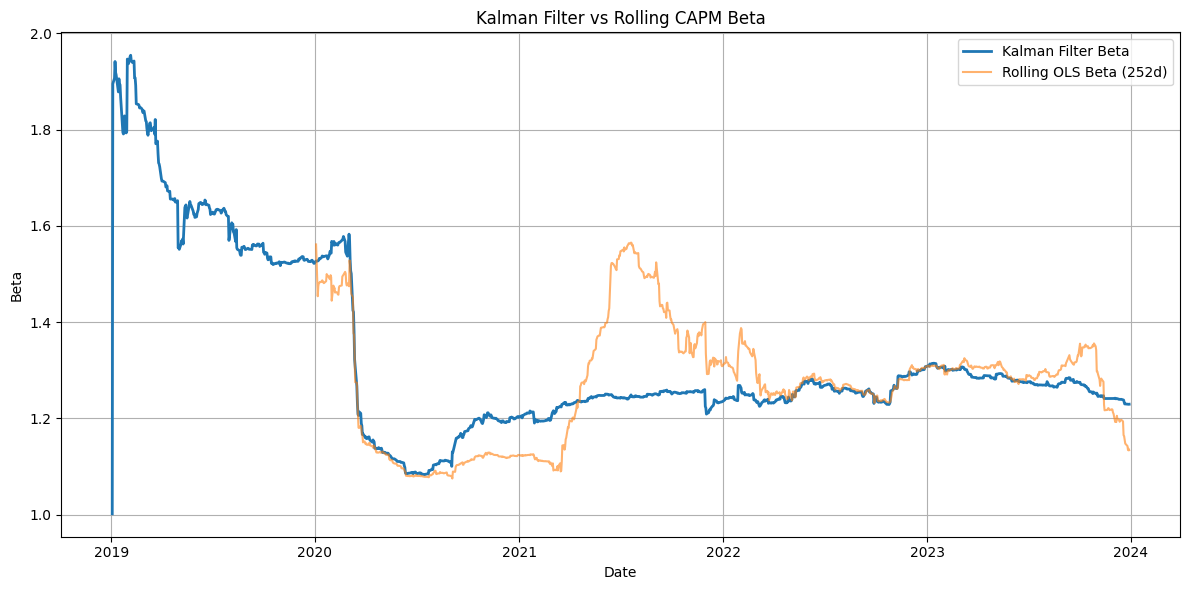

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(beta_kf, label="Kalman Filter Beta", linewidth=2)
plt.plot(rolling_beta_ols, label="Rolling OLS Beta (252d)", alpha=0.6)

plt.title("Kalman Filter vs Rolling CAPM Beta")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# What This Still Doesn’t Fix (Be Honest)

Even Kalman CAPM:

* Still single-factor
* Still assumes linearity
* Still sensitive to noise assumptions